# Telco Customer Churn Analysis
### Predicting customer churn using machine learning to identify at-risk customers for a telecom company.

In [1]:
import pandas as pd

## 1. Data Loading

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## 2. Initial Data Exploration

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(7043, 21)

Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null  

In [4]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [5]:
print(df["TotalCharges"].head(10))

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object


In [6]:
categorical_cols = df.select_dtypes(include = ["object"]).columns

numerical_cols = df.select_dtypes(exclude = ["object"]).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


In [7]:
print(df["Contract"].value_counts())

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


In [8]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


## 3. Exploratory Data Analysis (EDA)
Visualizing key patterns in the data before cleaning, to understand what drives churn.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

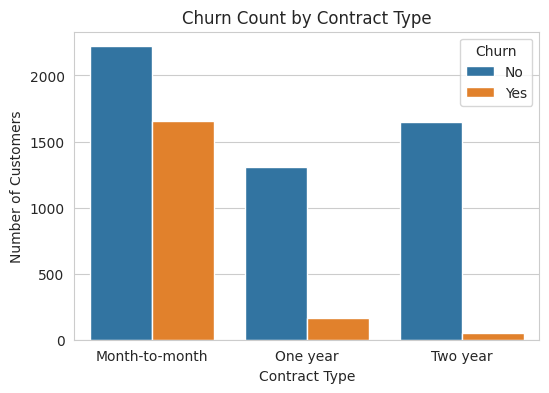

In [10]:
plt.figure(figsize = (6, 4))
sns.countplot(data = df, x = "Contract", hue = "Churn")
plt.title("Churn Count by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

**Insight:** Month-to-month customers churn at a much higher rate than those on 1 or 2-year contracts, suggesting contract length is a strong churn driver.

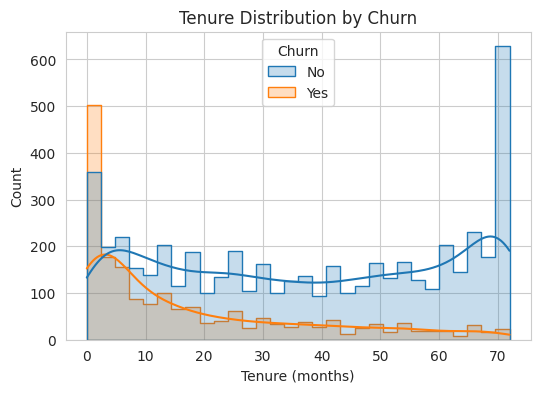

In [11]:
plt.figure(figsize = (6, 4))
sns.histplot(data = df, x = "tenure", hue = "Churn", bins = 30, kde = True, element = "step")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.show()

**Insight:** Customers with low tenure (new customers) churn more frequently than long-tenured customers, indicating early-stage loyalty risk.

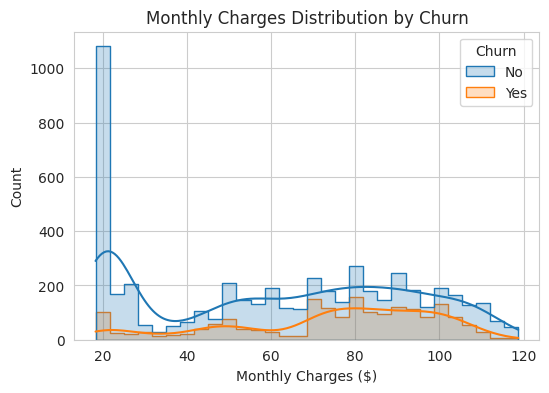

In [12]:
plt.figure(figsize = (6, 4))
sns.histplot(data = df, x = "MonthlyCharges", hue = "Churn", bins = 30, kde = True, element = "step")
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Count")
plt.show()

**Insight:** Customers with higher monthly charges show a higher tendency to churn, possibly due to price sensitivity.

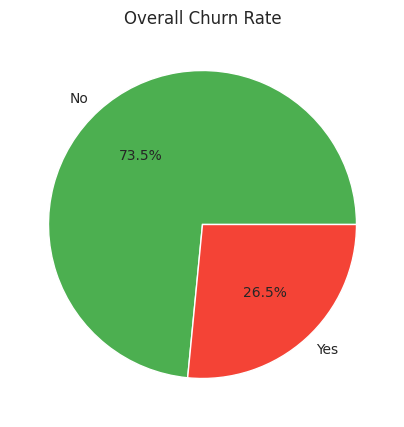

In [13]:
churn_rate = df["Churn"].value_counts(normalize = True) * 100

plt.figure(figsize = (5, 5))
plt.pie(churn_rate, labels = churn_rate.index, autopct = "%1.1f%%", colors = ["#4CAF50", "#F44336"])
plt.title("Overall Churn Rate")
plt.show()

**Insight:** Roughly 26.6% of customers in this dataset churned overall — this is the baseline rate our model needs to beat.

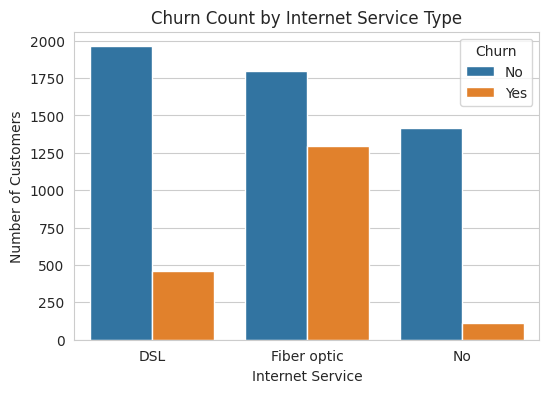

In [14]:
plt.figure(figsize = (6, 4))
sns.countplot(data = df, x = "InternetService", hue = "Churn")
plt.title("Churn Count by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

In [15]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize = "index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


**Insight:** Fiber optic customers churn at a significantly higher rate (approx 41.9%) compared to DSL customers (approx 19%) and customers with no internet service (approx 7.4%), suggesting service quality or pricing issues with the Fiber optic plan.

## 4. Data Cleaning
Converting TotalCharges to numeric and handling missing values.

In [16]:
print(df["TotalCharges"].str.strip().eq("").sum())

11


In [17]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], errors = "coerce"
)

df = df.dropna()

In [18]:
print(df.shape)

print(df.isnull().sum().sum())

(7032, 21)
0


## 5. Feature Preparation
Dropping irrelevant identifiers and encoding categorical variables.

In [19]:
df = df.drop("customerID", axis = 1)

print(df.shape)

(7032, 20)


In [20]:
print(df["Churn"].unique())

['No' 'Yes']


In [21]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [22]:
print(df["Churn"].head())

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [23]:
print(df["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [24]:
categorical_cols = df.select_dtypes(include = ["object"]).columns

print(categorical_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [25]:
for col in categorical_cols:
  print(f"\n{col}")
  print(df[col].unique())


gender
['Female' 'Male']

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


## 6. Encoding Categorical Variables

In [26]:
df_encoded = pd.get_dummies(df, drop_first = True)

print(df_encoded.shape)
print(df_encoded.head())

(7032, 31)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                   

In [27]:
X = df_encoded.drop("Churn", axis = 1)
y = df_encoded["Churn"]

print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


## 7. Train-Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (5625, 30)
Testing Set: (1407, 30)


## 8. Model Training — Logistic Regression (Baseline)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 5000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [30]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 1 0 0 0 0 1 0 0]


In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7882018479033405


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[915 118]
 [180 194]]


## 9. Feature Scaling
Scaling numerical features so Logistic Regression treats all features fairly (it's sensitive to feature magnitude).

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
model_scaled = LogisticRegression(max_iter = 1000)

model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))
print(confusion_matrix(y_test, y_pred_scaled))

Accuracy: 0.7874911158493249
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

[[915 118]
 [181 193]]


## 10. Handling Class Imbalance
Using class_weight="balanced" since churned customers are a minority class.

In [36]:
model_balanced = LogisticRegression(
    max_iter = 1000,
    class_weight = "balanced"
)

model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy: 0.7313432835820896
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407

[[733 300]
 [ 78 296]]


## 11. Model Training — Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(y_pred_rf[:10])

[0 0 1 0 0 0 0 1 0 0]


In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7853589196872779
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

[[927 106]
 [196 178]]


**Model Comparison Summary:**

| Model | Accuracy | Notes |
|---|---|---|
| Logistic Regression (baseline) | 78.82% | Good baseline model with balanced overall performance. |
| Logistic Regression (scaled) | 78.75% | Scaling had minimal impact on Logistic Regression performance. |
| Logistic Regression (balanced) | 73.13% | Lower accuracy but much higher recall (79%), making it better for identifying customers likely to churn. |
| Random Forest | 78.54% | Comparable accuracy with useful feature importance analysis, but lower recall than the balanced Logistic Regression. |

## 12. Feature Importance

In [39]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by = "Importance",
    ascending = False
)

print(feature_importance.head(10))

                           Feature  Importance
3                     TotalCharges    0.193409
2                   MonthlyCharges    0.169758
1                           tenure    0.167572
10     InternetService_Fiber optic    0.039999
28  PaymentMethod_Electronic check    0.035016
13              OnlineSecurity_Yes    0.028905
25               Contract_Two year    0.028618
4                      gender_Male    0.026971
19                 TechSupport_Yes    0.025829
26            PaperlessBilling_Yes    0.025044


## 13. Saving the Model

In [40]:
import joblib

joblib.dump(rf, "churn_model.pkl")

['churn_model.pkl']

In [41]:
loaded_model = joblib.load("churn_model.pkl")

loaded_prediction = loaded_model.predict(X_test)

print(loaded_prediction[:10])

[0 0 1 0 0 0 0 1 0 0]


## 14. Conclusion & Business Recommendations

**Key churn drivers identified:**
1. **Contract type** — Month-to-month customers churn far more than those on annual contracts.
2. **Tenure** — Newer customers (low tenure) are at the highest risk of leaving.
3. **Monthly charges** — Customers with higher monthly charges are more likely to churn.
4. **Internet service (Fiber optic)** — Fiber optic customers showed a significantly higher churn rate compared to DSL and customers with no internet service.

**Business recommendations:**
- Offer incentives (discounts, loyalty rewards, exclusive benefits) to encourage month-to-month customers to switch to annual or two-year contracts.
- Launch a "First 90 Days" onboarding and engagement program to improve retention among new customers.
- Review pricing strategies and provide personalized offers for customers with high monthly charges.
- Closely monitor Fiber optic customers by collecting feedback, improving service quality, and offering proactive retention incentives.
- Use the trained churn prediction model to identify high-risk customers early so the retention team can intervene before they leave.

**Model performance:** As shown in the model comparison table above, the balanced Logistic Regression achieved the best recall (79%) despite slightly lower accuracy, making it the most business-relevant choice for catching at-risk customers — see Section 11 for full metrics.